# Biomarker S8 — Holdout một lần như báo cáo, không dùng k-fold

**Vì sao có notebook này bên cạnh S7.** S7 dùng cross-validation 15 fold, cho con số trung thực nhất
nhưng **mỗi ca được dự đoán bởi một mô hình khác nhau**, và không tồn tại "mô hình cuối cùng" nào để
đem đi làm việc khác. Nhiều ý tưởng tiếp theo lại cần đúng hai thứ mà k-fold không cho: *một* mô hình
đã huấn luyện, và *một* tập test cố định. S8 sinh ra cho việc đó.

**Chia dữ liệu giống hệt báo cáo 13/9:** `GroupShuffleSplit(test_size=0.2, random_state=42)` theo
`subject`. Cỡ tập test rơi vào khoảng 246 ca, đúng con số trong báo cáo, nên mọi bảng ở đây so trực
tiếp được với Bảng 5 và Bảng 6.

**Mười một kiến trúc** — sáu cái của S7, cộng năm cái mới:

| | Model | Đầu dự đoán | Khác E ở đâu |
|---|---|---|---|
| A | XGB softmax (= S4 gốc) | — | — |
| A2 | MLP softmax, đối chứng cho D | Linear | — |
| B | XGB Frank & Hall | — | — |
| C | XGB hồi quy + điểm cắt tối ưu QWK | — | — |
| **C2** | **như C, nhưng huấn luyện có trọng số theo lớp** | — | (không phải biến thể của E) |
| D | MLP loss ngưỡng + L_mono | Linear | — |
| E | MLP đủ 4 thành phần loss của slide | Linear | **gốc so sánh** |
| **F** | **như E, nhưng đầu dự đoán là MLP** | **MLP 32→32→out** | đầu sâu hơn |
| **G** | **như E, nhưng ngưỡng dùng ASL thay BCE** | Linear | hàm loss ngưỡng |
| **H** | **như E, cộng ngưỡng quyết định `tau` học được** | Linear | `tau` **và** loss `exp` |
| **I** | **hai nhánh riêng cho bio và radiomics, gộp bằng α** | Linear | thân hai nhánh |

> **H đổi hai thứ, không phải một.** Bật `tau` bắt buộc phải bật kèm thành phần loss `exp`
> (expected-count), vì đó là đường gradient **duy nhất** chạy tới `tau` — BCE chỉ quan tâm từng
> ngưỡng đúng hay sai, không quan tâm *tổng* của chúng có ra đúng lớp không. Nên hiệu số của H không
> đọc được như đóng góp của riêng `tau`.

**Mục 4b là phần quan trọng nhất của bản này: tầng quyết định.** C có QWK cao nhất bảng nhưng recall
KL3 thấp nhất và recall KL4 cao nhất — nó đoán thừa hai lớp biên và bóp hai lớp giữa. Đó **không phải
lỗi của bộ hồi quy** mà là lỗi của mục tiêu đặt điểm cắt: QWK quadratic chính là hệ số tương hợp Lin,
mà điểm hồi quy luôn bị co về trung bình, nên cách rẻ nhất để tăng QWK là nới rộng hai bin ngoài
cùng. Mục 4b fit scorer **một lần** rồi áp nhiều quy tắc quyết định lên cùng bộ điểm honest, nên so
được các quy tắc **mà không train lại gì**.

**G, Asymmetric Loss — KẾT QUẢ ÂM TÍNH (13/9), giữ để đối chiếu.** Ý tưởng: phân rã ngưỡng biến KL
thành bài toán đa nhãn bốn nhãn nhị phân lệch rất khác nhau, và ca KL4 thật chỉ đạt trung bình
**0.46 tới 0.57** ở ngưỡng cuối (S7, lần chạy mới nhất) nên hiếm khi được đoán là KL4. Thực tế G là
**model tệ nhất trong cả 10, trên cả 5 feature set, theo cả QWK lẫn off-by≥2**. Nguyên nhân đã định
lượng được: hàm áp **một** `gamma_neg` cho **cả bốn** ngưỡng, trong khi chiều lệch của chúng **đảo
dấu** — `KL>0` có 76.9% dương (thiểu số là *âm*) còn `KL>3` chỉ 8.6% dương (thiểu số là *dương*). Hạ
trọng số âm dễ là đúng cho ngưỡng cuối và sai ngược cho hai ngưỡng đầu. Xem `Event.md` mục 13/9.

**H, ngưỡng học được.** Thêm `tau` một chiều cho mỗi ngưỡng, giải mã thành `z_k > tau_k` thay vì
`p_k > 0.5`, với thành phần loss liên tục khả vi của chính quy tắc giải mã:

    y_soft = Σ_k sigmoid((z_k − tau_k) / T)      và      MSE(y_soft, y)

Mục 7 đặt `tau` của H cạnh ngưỡng mà mục 4b **tìm được sau khi train** trên cùng model E. Hai cách,
cùng một câu hỏi: vạch quyết định nên nằm ở đâu thay vì 0.5.

**I, gộp theo nhóm đặc trưng.** `z = α·f_bio(x_bio) + β·f_rad(x_rad)` với `α + β = 1` được **bảo đảm
theo cấu trúc**: `α = sigmoid(gate)`, `β = 1 − α`. Giá trị của nó không nằm ở kappa mà ở chỗ `α`
**đọc được**.

> Đọc `α` cẩn thận. Nó là trọng số trên **biểu diễn đã học**, không phải tỉ lệ thông tin — một nhánh
> có thể cho vector biên độ lớn hơn rồi bù lại bằng `α` nhỏ. Và nó **khởi tạo ở 0.5**, lần chạy 13/9
> chỉ dịch tới 0.395–0.403, tức chưa loại trừ được khả năng gate gần như đứng yên. Phép kiểm nhận
> dạng: chạy lại với gate khởi tạo −2 và +2; nếu cả hai hội tụ về ~0.40 thì `α` có nghĩa.
> **I chỉ chạy được trên feature set có cả hai nhóm.** Với ba bộ không có radiomics, guard trong
> `OrdinalMLP` lùi về thân thường nên I **trùng khít E** — bảng ở mục 7 đánh dấu các dòng đó là
> "không áp dụng", không phải hiệu số 0.

> **S8 không thay thế S7.** Kappa của một lần chia dao động khoảng ±0.055, gấp bốn lần con số gộp
> out-of-fold của S7. **Dùng S8 để LOẠI, dùng S7 để KẾT LUẬN.** Mục 4c là các cổng quyết định quy tắc
> nào đáng đem sang S7.

## 0) Môi trường

In [1]:
# ============================================================
# Moi dinh nghia nam trong bsc/*.py - notebook chi goi.
# ============================================================
!pip install -q xgboost scikit-learn pandas matplotlib 2>/dev/null
from google.colab import drive
drive.mount("/content/drive")

REPO_URL, REPO_DIR = "https://github.com/AIVIETNAM-AIO-Tuan/bsCart-net.git", "/content/repo"
import os, sys
if not os.path.isdir(f"{REPO_DIR}/bsc"):
    !git clone -q $REPO_URL $REPO_DIR
!cd $REPO_DIR && git pull -q
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
for _m in [k for k in list(sys.modules) if k == "bsc" or k.startswith("bsc.")]:
    del sys.modules[_m]

import torch
from bsc import ordinal as ORD
from bsc.biomarkers import LEGACY_PREFIXES, SURFACE_PREFIXES
print("bsc.ordinal:", ORD.__file__, "| torch", torch.__version__)

Mounted at /content/drive
bsc.ordinal: /content/repo/bsc/ordinal.py | torch 2.11.0+cpu


## 1) Nạp bảng, tách 96 ca external, chọn feature set

Giống hệt S7. Nhãn tách external **luôn lấy lại từ manifest**, không tin cột trong bảng đặc trưng,
vì bảng S3 được sinh trước khi phép tách tồn tại.

In [ ]:
from pathlib import Path
import json, time
import numpy as np, pandas as pd

BIOM_DIR = Path("/content/drive/MyDrive/OAI_seg/knee_biomarkers_09_09")
V2_CSV = BIOM_DIR / "s6_fcl" / "biomarker_table_v2.csv"
S3_CSV = BIOM_DIR / "biomarker_table.csv"
COMBINED_CSV = BIOM_DIR / "combined_features_table.csv"
PREV_DIR = BIOM_DIR / "s8_holdout"                    # lan chay 13/9 - CHI DOC, de doi chieu
OUT_DIR = BIOM_DIR / "s8_holdout_v2"                  # MOI - khong ghi de gi cua lan truoc
OUT_DIR.mkdir(parents=True, exist_ok=True)
assert str(OUT_DIR).startswith("/content/drive/"), "Drive-first"

SRC = V2_CSV if V2_CSV.exists() else S3_CSV
assert SRC.exists(), f"khong thay {V2_CSV} lan {S3_CSV}"
df_all = pd.read_csv(SRC).drop_duplicates("case_id").reset_index(drop=True)
df_all = df_all.dropna(subset=["KL", "subject"]).copy()
df_all["KL"] = df_all["KL"].astype(int)

MANIFEST = BIOM_DIR / "cohort_manifest.csv"
SPLIT_COLS = ["source_dataset", "oaizib_split"]
man = pd.read_csv(MANIFEST).drop_duplicates("case_id")
have = [c for c in SPLIT_COLS if c in man.columns]
assert have, f"{MANIFEST.name} khong co cot danh dau external"
df_all = df_all.drop(columns=[c for c in have if c in df_all.columns], errors="ignore")
df_all = df_all.merge(man[["case_id"] + have], on="case_id", how="left")

is_ext = pd.Series(False, index=df_all.index)
if "source_dataset" in have:
    is_ext |= df_all["source_dataset"].astype(str).str.startswith("reserved_external_validation")
if "oaizib_split" in have:
    is_ext |= df_all["oaizib_split"].astype(str).str.contains("ext", case=False, na=False)
df = df_all[~is_ext].reset_index(drop=True)
print(f"tong {len(df_all)} | dung cho S8: {len(df)} | external giu rieng: {int(is_ext.sum())}")

legacy_cols = [c for c in df.columns if c.startswith(LEGACY_PREFIXES)]
surface_cols = [c for c in df.columns if c.startswith(SURFACE_PREFIXES)]
# Cung bo feature set voi S7 de hai notebook so duoc 1-1. `s6_surface_only` la bo QUAN
# TRONG nhat de tra loi "biomarker be mat MOT MINH manh den dau", dung bo qua.
FEATURE_SETS = {"legacy_s3": legacy_cols}
if surface_cols:
    FEATURE_SETS["s6_surface_only"] = surface_cols
    FEATURE_SETS["s6_all"] = legacy_cols + surface_cols
if COMBINED_CSV.exists():
    comb = pd.read_csv(COMBINED_CSV, low_memory=False).drop_duplicates("case_id")
    rad_cols = [c for c in comb.columns if c.startswith("rad_")]
    df = df.merge(comb[["case_id"] + rad_cols], on="case_id", how="left")
    FEATURE_SETS["s5_radiomics"] = legacy_cols + rad_cols
    if surface_cols:
        FEATURE_SETS["s6_all_plus_radiomics"] = legacy_cols + surface_cols + rad_cols
    print(f"nap {len(rad_cols)} cot radiomics")

# Nhan nhom dac trung cho nhanh fusion: TAT CA cot khong phai radiomics deu la "bio"
# (legacy hinh hoc + ho be mat cua S6). Mask nay di theo buoc chon dac trung o muc 4.
BIO_MASK = {fs: np.array([not c.startswith("rad_") for c in cols], bool)
            for fs, cols in FEATURE_SETS.items()}
print("ty le cot bio moi feature set:",
      {k: f"{v.sum()}/{len(v)}" for k, v in BIO_MASK.items()})

CLASSES = sorted(df["KL"].unique().tolist())
K = len(CLASSES)
y_idx = df["KL"].map({c: i for i, c in enumerate(CLASSES)}).to_numpy(np.int64)
groups = df["subject"].astype(str).to_numpy()
oa_target = (df["KL"] >= 2).to_numpy(np.float32)
print("so feature:", {k: len(v) for k, v in FEATURE_SETS.items()})
print("KL:", CLASSES, "| n moi lop:", np.bincount(y_idx, minlength=K).tolist())

## 2) Chia holdout một lần — chọn giữa hai cách

`SPLIT_MODE` quyết định:

| | Cách chia | KL4 trong test |
|---|---|---|
| `"report"` | `GroupShuffleSplit(test_size=0.2, random_state=42)` — **đúng như báo cáo** | 21.6 ± 4.0 |
| `"stratified"` | `ORD.stratified_group_split` — phân tầng theo lớp **trên subject** | **21.0 ± 0.23** |

Cả hai đều chia theo `subject`, không ca nào của cùng một người lọt cả hai phía.

**Vì sao không dùng `StratifiedGroupKFold` của sklearn.** Nghe thì đúng việc, nhưng đo trên chính
cohort này nó cho **20.7 ± 4.0** ca KL4, tức gần như không cải thiện gì so với chia ngẫu nhiên. Trong
một lần chia 5 fold, số ca KL4 chạy từ 16 tới 25. Lý do là tiêu chí tham lam của nó lấy *trung bình*
độ lệch trên mọi lớp, nên lớp hiếm gần như không ảnh hưởng tới quyết định và bị hy sinh để cân bằng
các lớp lớn. Hàm trong `bsc/ordinal.py` gộp ca theo subject rồi phân tầng **trên subject**, nên vừa
giữ được tỉ lệ lớp vừa không tách ai ra hai phía.

**Phân tầng chỉ khử dao động, không làm KL4 nhiều hơn.** Con số vẫn quanh 21 vì cohort chỉ có 106 ca
KL4. Muốn nhiều hơn thì phải tăng `TEST_SIZE`, và đánh đổi bằng dữ liệu huấn luyện: 0.25 cho khoảng
26 ca, 0.30 cho khoảng 32 ca. Với 21 ca thì **mỗi ca đoán đúng hay sai đổi recall gần 5 điểm phần
trăm**, nên đừng so hai model dựa trên recall KL4 ở đây — dùng S7 cho việc đó.

In [ ]:
SPLIT_MODE = "report"     # "stratified" = phan tang theo lop | "report" = giong bao cao
TEST_SIZE = 0.2
SPLIT_SEED = 42

if SPLIT_MODE == "report":
    from sklearn.model_selection import GroupShuffleSplit
    TR, TE = next(GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE,
                                    random_state=SPLIT_SEED).split(df, y_idx, groups))
else:
    TR, TE = ORD.stratified_group_split(y_idx, groups, test_size=TEST_SIZE, seed=SPLIT_SEED)

assert not (set(groups[TR]) & set(groups[TE])), "ro ri subject giua train va test"
df["split"] = np.where(np.isin(np.arange(len(df)), TE), "test", "train")
print(f"che do chia: {SPLIT_MODE} | train {len(TR)} ca / {len(set(groups[TR]))} subject "
      f"| test {len(TE)} ca / {len(set(groups[TE]))} subject")
print("bao cao 13/9 co n_test = 246")

# Phep chia PHAI trung khit lan truoc, neu khong moi con so v2 deu khong so duoc voi v1.
# Progress.md: "moi thu xay tiep phai DOC file nay thay vi chia lai".
PREV_SPLIT = PREV_DIR / "holdout_split.csv"
if PREV_SPLIT.exists():
    prev = pd.read_csv(PREV_SPLIT).drop_duplicates("case_id").set_index("case_id")["split"]
    thieu = int((~df["case_id"].isin(prev.index)).sum())
    assert thieu == 0, f"{thieu} ca khong co trong split da ghim"
    assert (df["case_id"].map(prev).to_numpy() == df["split"].to_numpy()).all(), \
        "phep chia KHAC lan truoc -> moi so v2 khong so duoc voi v1. Dung lai va kiem."
    print(f"da doi chieu: phep chia trung khit {PREV_DIR.name}/{PREV_SPLIT.name}")
else:
    print(f"(chua co {PREV_SPLIT} de doi chieu - day la lan chay dau)")

dist = pd.DataFrame({"cohort": np.bincount(y_idx, minlength=K),
                     "train": np.bincount(y_idx[TR], minlength=K),
                     "test": np.bincount(y_idx[TE], minlength=K)},
                    index=[f"KL{c}" for c in CLASSES])
dist["test_%"] = (dist["test"] / dist["test"].sum() * 100).round(1)
dist["cohort_%"] = (dist["cohort"] / dist["cohort"].sum() * 100).round(1)
display(dist)

n4 = int(dist.loc[f"KL{CLASSES[-1]}", "test"])
print(f"lop hiem nhat co {n4} ca trong test -> moi ca doi recall {100 / max(n4, 1):.1f} diem %")
if n4 < 18:
    print("CANH BAO: qua it de noi bat cu dieu gi ve lop do. Dung so cua S7 thay the.")

# Ghim lai ngay: moi thu xay tiep phai DOC file nay thay vi chia lai, neu khong hai thi
# nghiem se khong so duoc voi nhau.
df[["case_id", "subject", "KL", "split"]].to_csv(OUT_DIR / "holdout_split.csv", index=False)
print("da ghim split vao holdout_split.csv")

## 3) Mười một model — cùng train, cùng test

Siêu tham số giữ nguyên của S7 để so được. Chọn đặc trưng chạy **một lần trên tập train**, đúng theo
logic holdout: không có fold nào để chạy lại.

**Năm model cấp dữ liệu cho tầng quyết định** (B, C, C2, D, E) trả thêm ba khoá:

| Khoá | Là gì |
|---|---|
| `kind` | `"score"` (điểm liên tục, cần điểm cắt) hoặc `"p_thr"` (xác suất ngưỡng, cần thr từng `k`) |
| `inner` | điểm **honest** trên tập train, lấy bằng `ORD.inner_oof` — dùng để *fit* quy tắc quyết định |
| `score_te` | điểm thô trên tập test — dùng để *áp dụng* quy tắc, không train lại gì |

`inner_oof` dùng `GroupKFold(4)` **không shuffle**, đúng bằng các fold mà `cross_val_predict` cũ tạo
ra, nên dòng C tái lập **bit-đối-bit** so với lần chạy 13/9. Cell tiếp theo assert điều đó.

**C2 không phải biến thể của E.** Nó là trục cải tiến *khác*: đổi **điểm** bằng trọng số theo lớp,
thay vì đổi **điểm cắt**. Nó có điểm cắt của riêng nó và phải đọc tách khỏi các quy tắc của C.

In [ ]:
from xgboost import XGBClassifier, XGBRegressor
from sklearn.impute import SimpleImputer

XGB_KW = dict(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
              colsample_bytree=0.8, random_state=42, n_jobs=2)
MLP_EPOCHS = 400
HEAD_HIDDEN_F = (32,)      # F: moi head la MLP 32 -> 32 -> out, thay vi mot Linear

# ---------------------------------------------------------------------------------------
# Scorer nao cap du lieu cho TANG QUYET DINH (muc 4b) thi tra them ba khoa:
#   kind     "score" (diem lien tuc -> diem cat) | "p_thr" (xac suat nguong -> thr tung k)
#   inner    diem HONEST tren tap TRAIN (inner out-of-fold) - de fit quy tac quyet dinh
#   score_te diem tho tren tap TEST - de AP DUNG quy tac, khong train lai gi
# Nho vay so duoc nhieu quy tac quyet dinh tren CUNG mot scorer da fit.
# `inner_oof` dung GroupKFold(4) KHONG shuffle => trung khit cross_val_predict cu, nen dong
# C tai lap bit-doi-bit so voi lan chay 13/9.
# ---------------------------------------------------------------------------------------

def m_xgb_softmax(Xtr, ytr, Xte, **_):
    clf = XGBClassifier(objective="multi:softprob", num_class=K, eval_metric="mlogloss", **XGB_KW)
    clf.fit(Xtr, ytr)
    return dict(y_pred=clf.predict_proba(Xte).argmax(1), model=clf)

def m_xgb_frankhall(Xtr, ytr, Xte, gtr=None, **_):
    mk = lambda: XGBClassifier(objective="binary:logistic", eval_metric="logloss", **XGB_KW)
    inner = ORD.inner_oof(lambda Xa, ya, Xb: ORD.FrankHall(mk).fit(Xa, ya, K).predict_proba_thresholds(Xb),
                          Xtr, ytr, gtr)
    fh = ORD.FrankHall(mk).fit(Xtr, ytr, K)
    p = fh.predict_proba_thresholds(Xte)
    return dict(y_pred=ORD.decode_count(p), p_thr=p, y_alt=ORD.decode_cumdiff(p), model=fh,
                kind="p_thr", inner=inner, score_te=p)

def _xgb_reg(Xtr, ytr, Xte, gtr, w=None):
    """Bo hoi quy + diem cat mac dinh (toi uu QWK). `w` = trong so theo hang cho sample_weight."""
    fp = lambda Xa, ya, Xb, w=None: XGBRegressor(objective="reg:squarederror", **XGB_KW) \
        .fit(Xa, ya, sample_weight=w).predict(Xb)
    inner = ORD.inner_oof(fp, Xtr, ytr, gtr, row_kwargs=({"w": w} if w is not None else None))
    cuts = ORD.fit_cutpoints(inner, ytr, K)
    reg = XGBRegressor(objective="reg:squarederror", **XGB_KW).fit(Xtr, ytr, sample_weight=w)
    s_te = reg.predict(Xte)
    return dict(y_pred=ORD.apply_cutpoints(s_te, cuts), cuts=cuts, model=reg,
                kind="score", inner=inner, score_te=s_te)

def m_xgb_reg(Xtr, ytr, Xte, gtr=None, **_):
    return _xgb_reg(Xtr, ytr, Xte, gtr, w=None)

def m_xgb_reg_balanced(Xtr, ytr, Xte, gtr=None, **_):
    """TRUC KHAC voi tang quyet dinh: doi DIEM (bot co ve trung binh o lop hiem), khong doi cat.

    Doc rieng khoi cac quy tac cat cua C - no la mot scorer khac, co diem cat cua rieng no.
    """
    return _xgb_reg(Xtr, ytr, Xte, gtr, w=ORD.class_balanced_weights(ytr, K))

def _mlp_runner(lambdas, decode, head_hidden=(), asl=None, learn_thr=False, fusion=False,
                inner=False):
    def run(Xtr, ytr, Xte, oa_tr=None, bio_mask=None, gtr=None, **_):
        kw = dict(lambdas=lambdas, epochs=MLP_EPOCHS, seed=0, head_hidden=head_hidden,
                  asl=asl, learn_thresholds=learn_thr)
        model, info = ORD.train_ordinal_mlp(Xtr, ytr, K, oa_target=oa_tr,
                                            bio_mask=bio_mask if fusion else None, **kw)
        out = ORD.predict_ordinal_mlp(model, info, Xte)
        r = dict(y_pred=out[decode], model=model, info=info,
                 tau=info.get("tau"), alpha=info.get("alpha"))
        if lambdas.get("ord", 0) > 0:
            r["p_thr"] = out["p_thr"]
            r["y_alt"] = out["y_softmax"] if lambdas.get("cls", 0) > 0 else out["y_cumdiff"]
        if inner:
            def fp(Xa, ya, Xb, oa=None):
                m, i = ORD.train_ordinal_mlp(Xa, ya, K, oa_target=oa, bio_mask=None, **kw)
                return ORD.predict_ordinal_mlp(m, i, Xb)["p_thr"]
            r.update(kind="p_thr", score_te=out["p_thr"],
                     inner=ORD.inner_oof(fp, Xtr, ytr, gtr,
                                         row_kwargs=({"oa": oa_tr} if oa_tr is not None else None)))
        return r
    return run

MODELS = {
    "A_xgb_softmax":       m_xgb_softmax,
    "A2_mlp_softmax":      _mlp_runner(ORD.SOFTMAX_ONLY_LAMBDAS, "y_softmax"),
    "B_xgb_frankhall":     m_xgb_frankhall,
    "C_xgb_reg_cutpoints": m_xgb_reg,
    "C2_xgb_reg_balanced": m_xgb_reg_balanced,
    "D_mlp_ordinal_only":  _mlp_runner(ORD.ORDINAL_ONLY_LAMBDAS, "y_count", inner=True),
    "E_mlp_slide":         _mlp_runner(ORD.SLIDE_LAMBDAS, "y_count", inner=True),
    "F_mlp_slide_mlphead": _mlp_runner(ORD.SLIDE_LAMBDAS, "y_count", HEAD_HIDDEN_F),
    # G: doi BCE -> ASL o thanh phan nguong. KET QUA AM TINH 13/9 - giu de doi chieu.
    "G_mlp_asl":           _mlp_runner(ORD.ASL_LAMBDAS, "y_count", asl=ORD.ASL_KW),
    # H: nguong quyet dinh la THAM SO HOC DUOC (tau), giai ma bang z_k > tau_k.
    "H_mlp_learned_thr":   _mlp_runner(ORD.LEARNED_THR_LAMBDAS, "y_count_tau", learn_thr=True),
    # I: hai nhanh rieng cho bio va radiomics, gop bang alpha + beta = 1.
    "I_mlp_fusion":        _mlp_runner(ORD.SLIDE_LAMBDAS, "y_count", fusion=True),
}
print("so model:", len(MODELS),
      "| cap du lieu cho tang quyet dinh:",
      ["B_xgb_frankhall", "C_xgb_reg_cutpoints", "C2_xgb_reg_balanced",
       "D_mlp_ordinal_only", "E_mlp_slide"])

## 4) Chạy — một lần train, một lần test

In [ ]:
SELECT_ABOVE = 120

rows, PRED, FITTED, KEEP_COLS = [], {}, {}, {}
t0 = time.time()
for fs_name, cols in FEATURE_SETS.items():
    X_all = df[cols].to_numpy(np.float32)
    imp = SimpleImputer(strategy="median").fit(X_all[TR])        # fit CHI tren train
    Xtr, Xte = imp.transform(X_all[TR]), imp.transform(X_all[TE])
    bmask = BIO_MASK[fs_name]
    keep = np.arange(len(cols))
    if len(cols) > SELECT_ABOVE:
        keep = ORD.select_features(Xtr, y_idx[TR], seed=0)        # fit CHI tren train
        Xtr, Xte = Xtr[:, keep], Xte[:, keep]
        bmask = bmask[keep]                                       # mask di theo buoc chon
        print(f"{fs_name}: {len(cols)} -> {len(keep)} cot sau khi chon "
              f"({int(bmask.sum())} bio / {int((~bmask).sum())} radiomics)")
    # Giu lai TEN cot da chon: muc 4c can no de tra loi "cot S6 nao song sot".
    KEEP_COLS[fs_name] = [cols[i] for i in keep]
    for m_name, fn in MODELS.items():
        r = fn(Xtr, y_idx[TR], Xte, gtr=groups[TR], oa_tr=oa_target[TR], bio_mask=bmask)
        yp = np.asarray(r["y_pred"], np.int64)
        PRED[(fs_name, m_name)] = yp
        FITTED[(fs_name, m_name)] = r
        rows.append(dict(feature_set=fs_name, model=m_name, decode="default", n_test=len(TE),
                         qwk=ORD.qwk(y_idx[TE], yp, K),
                         acc=float((yp == y_idx[TE]).mean()),
                         mae=ORD.mae(y_idx[TE], yp),
                         off_by_2=ORD.off_by_rate(y_idx[TE], yp, 2),
                         alpha=r.get("alpha")))
res = pd.DataFrame(rows)
res.to_csv(OUT_DIR / "holdout_metrics.csv", index=False)
print(f"xong trong {(time.time() - t0) / 60:.1f} phut")

# ---- Doi chieu voi lan chay 13/9 -------------------------------------------------------
# XGB o day la tat dinh, nen A/B/C PHAI trung khit. Neu C lech thi `inner_oof` khong cho
# cung fold voi `cross_val_predict` cu => diem cat doi => moi so cua C khong so duoc nua.
# MLP co the lech giua cac ban dung torch khac nhau, nen chi IN, khong assert.
PREV_METRICS = PREV_DIR / "holdout_metrics.csv"
if PREV_METRICS.exists():
    old = pd.read_csv(PREV_METRICS)
    chung = res.merge(old[["feature_set", "model", "qwk"]], on=["feature_set", "model"],
                      suffixes=("", "_cu"))
    d = chung.assign(d=lambda x: (x.qwk - x.qwk_cu).abs()).groupby("model")["d"].max()
    print("\nlech QWK lon nhat so voi lan truoc, theo model:")
    display(d.round(4).to_frame("max |d qwk|"))
    for m in ["A_xgb_softmax", "B_xgb_frankhall", "C_xgb_reg_cutpoints"]:
        if m in d.index:
            assert d[m] < 1e-9, (f"{m} lech {d[m]:.4g} so voi lan truoc - XGB la tat dinh nen "
                                 "khong duoc lech. Kiem inner_oof truoc khi doc tiep.")
    print("A/B/C tai lap bit-doi-bit. Dong MLP chi in de tham khao.")
else:
    print(f"(chua co {PREV_METRICS} de doi chieu)")

## 4b) Tầng quyết định — nhiều quy tắc trên **cùng** một scorer đã fit

**Vấn đề.** C có QWK cao nhất bảng (0.803) nhưng recall KL3 thấp nhất trong 10 model (48.3%) và
recall KL4 cao nhất (80.8%) với precision KL4 chỉ 72.4%. Nghĩa là nó **đoán thừa hai lớp biên và
bóp hai lớp giữa**.

**Đó không phải lỗi của bộ hồi quy, mà là lỗi của mục tiêu đặt điểm cắt.** QWK quadratic bằng

    2·Cov(y, ŷ) / (Var y + Var ŷ + (μy − μŷ)²)

tức hệ số tương hợp Lin. Điểm hồi quy luôn bị **co về trung bình**, `Var(score) < Var(y)`. Cách rẻ
nhất để đẩy phân số đó lên là **bơm `Var(ŷ)`**, và cách bơm là nới rộng hai bin ngoài cùng. Thuật
toán tìm điểm cắt theo QWK làm đúng như vậy — không phải nó hỏng, mà nó đang tối ưu đúng cái ta bảo.

**Hệ quả: đổi mục tiêu đặt cắt là đủ, không cần train lại gì.** Cell này fit scorer **một lần**, giữ
điểm honest inner-out-of-fold trên tập train, rồi áp nhiều quy tắc quyết định lên cùng bộ điểm đó.

| Quy tắc | Áp cho | Ý tưởng |
|---|---|---|
| `qwk` | điểm liên tục | mặc định hiện tại — nới bin ngoài |
| `quantile` | điểm liên tục | cắt sao cho **tỉ lệ dự đoán = tỉ lệ thật**, không có tham số nào để fit |
| `macro_recall` | điểm liên tục | tối ưu thẳng macro-recall — **bất ổn**, chỉ để hiện frontier |
| `mr_slack0.02` | điểm liên tục | macro-recall với ràng buộc QWK không tụt quá 0.02 |
| `minrec0.40` | điểm liên tục | sàn recall 0.40 cho mọi lớp |
| `fixed0.5` | xác suất ngưỡng | vạch 0.5 cố định — mặc định hiện tại |
| `tuned_qwk` | xác suất ngưỡng | ngưỡng riêng từng `k`, tối ưu QWK |
| `tuned_mr_slack0.02` | xác suất ngưỡng | ngưỡng riêng từng `k`, macro-recall có ràng buộc |

**Cột `optimism`** = macro-recall trên inner trừ macro-recall trên test. Đây là thước đo trực tiếp
mức **overfit vị trí cắt**. Trên dữ liệu tổng hợp, `macro_recall` không ràng buộc tệ hơn cả hai mặt
ở 2/4 seed, nên đừng thăng hạng nó chỉ dựa vào S8.

**Cột `inconsistent_pattern`** chỉ có nghĩa với `p_thr`: ngưỡng tinh chỉnh **không bị ép đơn điệu**
(tối ưu đo được là `[0.65, 0.35, 0.55, 0.20]`, ép sẽ chặn đúng cái cần sửa), nên phép đếm có thể
nhận mẫu kiểu `[1,0,1,0]`. Đo và báo cáo, không chặn.

In [ ]:
SLACK = 0.02       # QWK duoc phep tut toi da bao nhieu de doi lay recall
MIN_REC = 0.40     # san recall cho moi lop

DECODES = {
    "score": {
        "qwk":          lambda s, y: ORD.fit_cutpoints(s, y, K),
        "quantile":     lambda s, y: ORD.quantile_cutpoints(s, y, K),
        "macro_recall": lambda s, y: ORD.fit_cutpoints(s, y, K, objective="macro_recall"),
        f"mr_slack{SLACK}": lambda s, y: ORD.fit_cutpoints(s, y, K, objective="macro_recall",
                                                           qwk_slack=SLACK),
        f"minrec{MIN_REC}": lambda s, y: ORD.fit_cutpoints(s, y, K, min_recall=MIN_REC),
    },
    "p_thr": {
        "fixed0.5":  lambda p, y: np.full(p.shape[1], 0.5),
        "tuned_qwk": lambda p, y: ORD.fit_threshold_cuts(p, y, K),
        f"tuned_mr_slack{SLACK}": lambda p, y: ORD.fit_threshold_cuts(p, y, K,
                                                                      objective="macro_recall",
                                                                      qwk_slack=SLACK),
    },
}
APPLY = {"score": ORD.apply_cutpoints, "p_thr": lambda p, thr: ORD.decode_count(p, thr=thr)}

rows_dec, RULES = [], {}
t0 = time.time()
for (fs, m), r in FITTED.items():
    if "inner" not in r:
        continue
    kind = r["kind"]
    for dec, rule in DECODES[kind].items():
        prm = np.asarray(rule(r["inner"], y_idx[TR]), np.float64)
        yp_in = APPLY[kind](r["inner"], prm)
        yp = APPLY[kind](r["score_te"], prm)
        PRED[(fs, f"{m}@{dec}")] = yp
        RULES[f"{fs}|{m}|{dec}"] = np.round(prm, 4).tolist()
        prf = ORD.per_class_prf(y_idx[TE], yp, K)
        rec = prf["recall"]
        rows_dec.append(dict(
            feature_set=fs, model=m, decode=dec,
            qwk=ORD.qwk(y_idx[TE], yp, K),
            macro_recall=float(rec.mean()),
            min_recall=float(rec.min()), min_class=f"KL{CLASSES[int(rec.argmin())]}",
            acc=float((yp == y_idx[TE]).mean()),
            mae=ORD.mae(y_idx[TE], yp),
            off_by_2=ORD.off_by_rate(y_idx[TE], yp, 2),
            recall_KL3=float(rec[3]) if K > 3 else np.nan,
            recall_KL4=float(rec[-1]), precision_KL4=float(prf["precision"][-1]),
            # optimism > 0 tuc quy tac dang OVERFIT vi tri cat tren tap train
            optimism=ORD.macro_recall(y_idx[TR], yp_in, K) - float(rec.mean()),
            inconsistent_pattern=(ORD.monotonic_violation_rate((r["score_te"] > prm).astype(float))
                                  if kind == "p_thr" else np.nan),
            pred_marginal=np.bincount(yp, minlength=K).tolist(),
            params=np.round(prm, 3).tolist()))

res_dec = pd.DataFrame(rows_dec)
res_dec.to_csv(OUT_DIR / "decision_layer.csv", index=False)
json.dump(RULES, open(OUT_DIR / "decision_rules.json", "w"), indent=2)
print(f"{len(res_dec)} dong quyet dinh trong {time.time() - t0:.0f}s "
      f"| marginal THAT tren test: {np.bincount(y_idx[TE], minlength=K).tolist()}")

# ---- Chot: quy tac "mac dinh" phai TRUNG KHIT dong goc, khong duoc lech mot ca nao --------
for (fs, m), r in FITTED.items():
    if "inner" not in r:
        continue
    base = {"score": "qwk", "p_thr": "fixed0.5"}[r["kind"]]
    assert np.array_equal(PRED[(fs, f"{m}@{base}")], PRED[(fs, m)]), \
        f"{fs}/{m}: quy tac '{base}' khac dong goc -> tang quyet dinh dang doc sai diem"
print("da chot: qwk == C mac dinh, fixed0.5 == B/D/E mac dinh.")

# ---- Bang frontier ----------------------------------------------------------------------
COLS = ["decode", "qwk", "macro_recall", "min_recall", "min_class", "off_by_2",
        "recall_KL3", "recall_KL4", "precision_KL4", "optimism"]
for fs in [c for c in ["s6_all_plus_radiomics", "s5_radiomics"] if c in FEATURE_SETS]:
    print(f"\n===== {fs} (n_test={len(TE)}) — cao hon tot hon tru off_by_2 va optimism")
    for m in res_dec[res_dec.feature_set == fs].model.unique():
        sub = res_dec[(res_dec.feature_set == fs) & (res_dec.model == m)]
        print(f"\n--- {m}")
        display(sub[COLS].sort_values("macro_recall", ascending=False)
                .set_index("decode").round(3))

## 4c) Quy tắc thăng hạng — cái nào đáng đem sang S7

S8 là **một lần chia**, dao động ±0.055 QWK. Nó dùng để **loại**, không dùng để kết luận. Một quy tắc
chỉ được đem sang S7 khi vượt **cả năm** cổng dưới đây, trên **cả hai** bộ đặc trưng có radiomics:

| Cổng | Ngưỡng | Vì sao |
|---|---|---|
| macro-recall | `≥ ref + 0.05` | phải thật sự hồi phục lớp giữa, không phải nhiễu |
| QWK | `≥ ref − 0.02` | bạn đã chọn hướng "giữ QWK gần tối đa" |
| off-by≥2 | `≤ ref + 0.02` | không được mua recall bằng lỗi lâm sàng nặng |
| optimism | `≤ 0.05` | quy tắc overfit vị trí cắt thì sẽ sụp trên S7 |
| bootstrap CI | không chứa 0 | KL4 chỉ có 26 ca test, một ca đổi 3.8 điểm recall |

`ref` là quy tắc mặc định của **chính scorer đó** (`qwk` cho C/C2, `fixed0.5` cho B/D/E), nên mỗi
scorer được chấm so với chính nó.

In [ ]:
GATE = dict(d_macro_recall=0.05, d_qwk=-0.02, d_off_by_2=0.02, max_optimism=0.05)
FS_GATE = [c for c in ["s6_all_plus_radiomics", "s5_radiomics"] if c in FEATURE_SETS]
BASE_DEC = {"score": "qwk", "p_thr": "fixed0.5"}

rows_g = []
for fs in FS_GATE:
    for m in res_dec[res_dec.feature_set == fs].model.unique():
        kind = FITTED[(fs, m)]["kind"]
        ref_dec = BASE_DEC[kind]
        sub = res_dec[(res_dec.feature_set == fs) & (res_dec.model == m)].set_index("decode")
        ref = sub.loc[ref_dec]
        for dec, row in sub.iterrows():
            if dec == ref_dec:
                continue
            bs = ORD.bootstrap_delta(y_idx[TE], PRED[(fs, f"{m}@{ref_dec}")],
                                     PRED[(fs, f"{m}@{dec}")], "macro_recall", K,
                                     n_boot=2000, seed=0)
            g = dict(
                mr=row.macro_recall - ref.macro_recall >= GATE["d_macro_recall"],
                qwk=row.qwk - ref.qwk >= GATE["d_qwk"],
                off2=row.off_by_2 - ref.off_by_2 <= GATE["d_off_by_2"],
                opt=row.optimism <= GATE["max_optimism"],
                ci=bs["ci_low"] > 0)
            rows_g.append(dict(feature_set=fs, model=m, decode=dec,
                               d_macro_recall=round(row.macro_recall - ref.macro_recall, 3),
                               d_qwk=round(row.qwk - ref.qwk, 3),
                               d_off_by_2=round(row.off_by_2 - ref.off_by_2, 3),
                               optimism=round(row.optimism, 3),
                               ci=f"[{bs['ci_low']:+.3f}, {bs['ci_high']:+.3f}]",
                               **{f"g_{k}": v for k, v in g.items()},
                               dat=all(g.values())))
gates = pd.DataFrame(rows_g)
gates.to_csv(OUT_DIR / "promotion_gates.csv", index=False)
print("Cong thang hang (ref = quy tac mac dinh cua CHINH scorer do):")
display(gates.set_index(["feature_set", "model", "decode"]))

# Chi thang hang khi DAT tren MOI feature set co radiomics - mot lan chia thi de an may
dat = (gates.groupby(["model", "decode"])["dat"].agg(["sum", "count"])
       .query(f"sum == count and count == {len(FS_GATE)}"))
print()
if len(dat):
    print("=> DEM SANG S7:")
    for m, d in dat.index:
        print(f"   {m} @ {d}")
else:
    print("=> KHONG quy tac nao dat tren ca hai feature set. Doc bang frontier o 4b de hieu vi sao,")
    print("   va nho: S8 dung de LOAI, khong dung de ket luan.")

## 4d) Cột S6 có được dùng không — chẩn đoán, không phải metric

**Câu hỏi.** Khi đã có radiomics, thêm cột bề mặt S6 chỉ nhích QWK +0.004 tới +0.026, nằm trong
nhiễu. Nhưng khi **không** có radiomics thì S6 thêm +0.06 tới +0.09 cho mọi model. Vậy trong bộ đầy
đủ, S6 bị bỏ đi hay được giữ mà vô dụng?

Hai trạng thái đó trả lời câu hỏi **rất khác nhau**, nên phải tách:

- **LASSO bỏ** — cột không sống sót bước chọn đặc trưng. Nghĩa là nó tương quan mạnh với một cột
  radiomics nào đó, tức radiomics **đã chứa** thông tin hình học.
- **Giữ nhưng gain 0** — cột qua được LASSO nhưng XGB không bao giờ tách trên nó. Nghĩa là nó sống
  sót vì tương quan thấp chứ không phải vì mang tín hiệu.
- **Giữ và có gain** — cột thật sự đóng góp.

Gain lấy từ model **A** (XGB softmax) vì nó là cây đơn thuần, đọc trực tiếp được. Khoá của booster
là `f{i}` theo **cột đã giữ**, khoá vắng mặt nghĩa là chưa từng tách trên cột đó.

In [ ]:
def ho_cua(c):
    if c.startswith("rad_"):
        return "radiomics"
    return "S6_surface" if c.startswith(SURFACE_PREFIXES) else "legacy"

rows_s6 = []
for fs, cols in FEATURE_SETS.items():
    kept = KEEP_COLS[fs]
    kept_set = set(kept)
    gain = {}
    mdl = FITTED[(fs, "A_xgb_softmax")]["model"]
    try:
        raw = mdl.get_booster().get_score(importance_type="gain")   # khoa 'f{i}' tren cot DA GIU
        gain = {kept[int(k[1:])]: v for k, v in raw.items() if int(k[1:]) < len(kept)}
    except Exception as e:
        print(f"{fs}: khong doc duoc gain ({e!r})")
    tong = sum(gain.values()) or 1.0
    for c in cols:
        rows_s6.append(dict(feature_set=fs, cot=c, ho=ho_cua(c),
                            trang_thai=("LASSO_bo" if c not in kept_set else
                                        ("giu_gain_0" if gain.get(c, 0.0) <= 0 else "giu_co_gain")),
                            gain=float(gain.get(c, 0.0)),
                            gain_pct=100.0 * float(gain.get(c, 0.0)) / tong))
s6 = pd.DataFrame(rows_s6)
s6.to_csv(OUT_DIR / "s6_survival.csv", index=False)

print("So cot theo trang thai (hang = ho dac trung):")
for fs in FEATURE_SETS:
    sub = s6[s6.feature_set == fs]
    piv = sub.pivot_table(index="ho", columns="trang_thai", values="cot",
                          aggfunc="count", fill_value=0)
    share = sub.groupby("ho")["gain_pct"].sum().round(1)
    piv["ty_trong_gain_%"] = share
    print(f"\n--- {fs} ({len(sub)} cot vao, {len(KEEP_COLS[fs])} cot giu)")
    display(piv)

FS_S6 = "s6_all_plus_radiomics"
if FS_S6 in FEATURE_SETS:
    sub = s6[(s6.feature_set == FS_S6) & (s6.ho == "S6_surface")]
    print(f"\n===== {FS_S6}: cot S6 song sot, xep theo gain")
    top = sub[sub.trang_thai == "giu_co_gain"].sort_values("gain", ascending=False)
    if len(top):
        display(top[["cot", "gain", "gain_pct"]].head(15).round(3).set_index("cot"))
        rank = (s6[s6.feature_set == FS_S6].sort_values("gain", ascending=False)
                .reset_index(drop=True))
        hang = rank.index[rank.ho == "S6_surface"].tolist()
        print(f"cot S6 dung dau nam o hang {hang[0] + 1} / {len(rank)} toan bang")
    else:
        print("KHONG cot S6 nao vua song sot LASSO vua duoc XGB tach tren no.")
    print(f"\nTy trong gain cua tung ho: "
          f"{s6[s6.feature_set == FS_S6].groupby('ho')['gain_pct'].sum().round(1).to_dict()}")

## 5) Kết quả — định dạng như Bảng 5 của báo cáo

`off_by_2` là tỉ lệ ca lệch từ 2 bậc KL trở lên, chính là cột mà báo cáo gọi là lỗi lâm sàng nghiêm
trọng nhất. Báo cáo đo được 22.0% cho S4 gốc, 9.3% cho nominal 93 cột, 7.3% cho Frank-Hall và 6.5%
cho Regression.

--- legacy_s3 (n_test=246)


,acc,qwk,mae,off_by_2
model,,,,
A_xgb_softmax,41.1,0.532,0.862,22.0
A2_mlp_softmax,43.5,0.594,0.805,18.7
B_xgb_frankhall,41.9,0.557,0.776,17.5
C_xgb_reg_cutpoints,38.2,0.604,0.837,18.7
D_mlp_ordinal_only,43.5,0.625,0.724,13.8
E_mlp_slide,43.5,0.611,0.732,14.2
F_mlp_slide_mlphead,46.7,0.608,0.728,16.7
G_mlp_asl,31.7,0.442,0.992,27.6
H_mlp_learned_thr,40.2,0.600,0.780,15.4


--- s6_surface_only (n_test=246)


,acc,qwk,mae,off_by_2
model,,,,
A_xgb_softmax,37.4,0.537,0.898,21.1
A2_mlp_softmax,41.5,0.588,0.829,20.7
B_xgb_frankhall,37.0,0.586,0.797,14.6
C_xgb_reg_cutpoints,40.7,0.663,0.768,15.4
D_mlp_ordinal_only,39.4,0.615,0.764,14.6
E_mlp_slide,39.8,0.651,0.732,12.2
F_mlp_slide_mlphead,40.7,0.648,0.736,13.4
G_mlp_asl,37.0,0.473,0.911,24.0
H_mlp_learned_thr,41.9,0.623,0.756,15.4


--- s6_all (n_test=246)


,acc,qwk,mae,off_by_2
model,,,,
A_xgb_softmax,40.7,0.635,0.793,18.3
A2_mlp_softmax,45.1,0.638,0.752,18.7
B_xgb_frankhall,44.7,0.699,0.663,10.6
C_xgb_reg_cutpoints,45.5,0.702,0.695,14.2
D_mlp_ordinal_only,50.8,0.703,0.614,10.6
E_mlp_slide,49.6,0.698,0.638,11.8
F_mlp_slide_mlphead,51.2,0.718,0.618,12.2
G_mlp_asl,36.6,0.555,0.854,19.1
H_mlp_learned_thr,52.4,0.691,0.638,15.0


--- s5_radiomics (n_test=246)


,acc,qwk,mae,off_by_2
model,,,,
A_xgb_softmax,50.8,0.753,0.589,8.9
A2_mlp_softmax,57.7,0.757,0.549,11.0
B_xgb_frankhall,52.4,0.776,0.537,6.1
C_xgb_reg_cutpoints,52.8,0.793,0.549,7.7
D_mlp_ordinal_only,55.3,0.792,0.520,6.9
E_mlp_slide,55.7,0.770,0.541,8.5
F_mlp_slide_mlphead,53.7,0.779,0.545,8.1
G_mlp_asl,50.8,0.727,0.610,10.2
H_mlp_learned_thr,53.3,0.750,0.569,8.9


--- s6_all_plus_radiomics (n_test=246)


,acc,qwk,mae,off_by_2
model,,,,
A_xgb_softmax,51.2,0.750,0.593,9.8
A2_mlp_softmax,52.0,0.761,0.577,8.9
B_xgb_frankhall,53.3,0.783,0.528,6.1
C_xgb_reg_cutpoints,54.5,0.803,0.520,6.1
D_mlp_ordinal_only,53.7,0.793,0.524,5.3
E_mlp_slide,57.3,0.796,0.504,7.3
F_mlp_slide_mlphead,56.5,0.790,0.508,6.5
G_mlp_asl,52.4,0.745,0.593,11.4
H_mlp_learned_thr,51.2,0.783,0.561,7.3


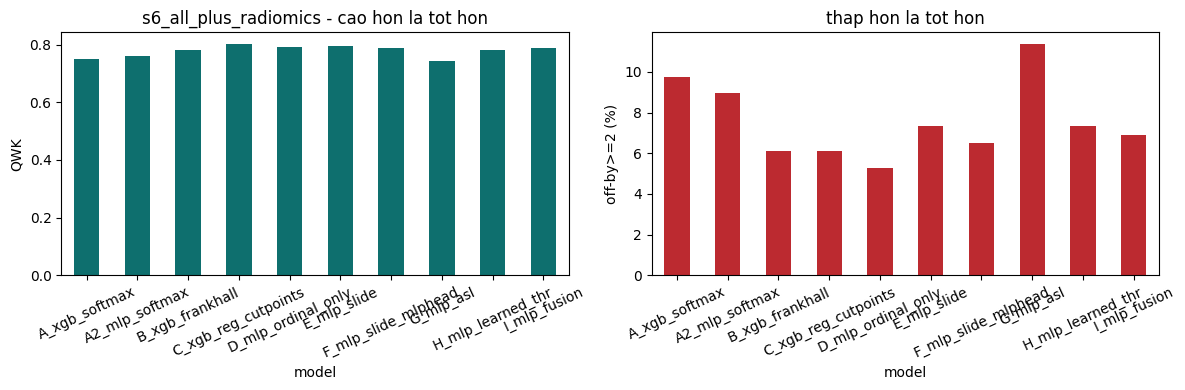

In [6]:
import matplotlib.pyplot as plt

for fs in FEATURE_SETS:
    sub = res[res.feature_set == fs].set_index("model")[["acc", "qwk", "mae", "off_by_2"]]
    print(f"--- {fs} (n_test={len(TE)})")
    display(sub.assign(acc=lambda d: (d.acc * 100).round(1),
                       off_by_2=lambda d: (d.off_by_2 * 100).round(1)).round(3))

fs0 = list(FEATURE_SETS)[-1]
sub = res[res.feature_set == fs0].set_index("model")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sub["qwk"].plot.bar(ax=ax[0], rot=25, color="#0E6F6E")
ax[0].set_ylabel("QWK"); ax[0].set_title(fs0 + " - cao hon la tot hon")
(sub["off_by_2"] * 100).plot.bar(ax=ax[1], rot=25, color="#BC2A30")
ax[1].set_ylabel("off-by>=2 (%)"); ax[1].set_title("thap hon la tot hon")
plt.tight_layout(); plt.savefig(OUT_DIR / "holdout_metrics.png", dpi=130); plt.show()

## 6) Precision / Recall / F1 theo lớp + ma trận nhầm lẫn

So trực tiếp được với Bảng 6 của báo cáo, vì cùng cỡ tập test và cùng cách chia.

In [ ]:
# MOT dinh nghia: per_class_prf nam trong bsc/ordinal.py, khong goi sklearn inline nua
# (truoc day S7 va S8 moi cai giu mot ban, va chung da bat dau troi khac nhau).
rows = []
for (fs, m_name), yp in PRED.items():
    prf = ORD.per_class_prf(y_idx[TE], yp, K)
    for k in range(K):
        rows.append(dict(feature_set=fs, model=m_name, KL=str(CLASSES[k]), n=int(prf["support"][k]),
                         precision=prf["precision"][k], recall=prf["recall"][k], f1=prf["f1"][k]))
    rows.append(dict(feature_set=fs, model=m_name, KL="macro", n=int(prf["support"].sum()),
                     precision=prf["precision"].mean(), recall=prf["recall"].mean(),
                     f1=prf["f1"].mean()))
per_class = pd.DataFrame(rows)
per_class.to_csv(OUT_DIR / "holdout_per_class.csv", index=False)

FS_SHOW = list(FEATURE_SETS)[-1]
# PRED gio chua ca khoa "model@decode" cua muc 4b -> bang nay phu luon moi quy tac quyet dinh
sub = per_class[per_class.feature_set == FS_SHOW]
print("feature set dang hien:", FS_SHOW, "|", sub.model.nunique(), "dong (ke ca @decode)")
for metric in ["recall", "precision", "f1"]:
    print()
    print(metric.upper() + " theo lop (%)")
    display((sub.pivot(index="model", columns="KL", values=metric) * 100).round(1))

for m_name in ["A_xgb_softmax", "B_xgb_frankhall", "C_xgb_reg_cutpoints",
               "C_xgb_reg_cutpoints@quantile", "F_mlp_slide_mlphead"]:
    if (FS_SHOW, m_name) in PRED:
        print()
        print("confusion - " + m_name + " (hang = that, cot = doan)")
        print(ORD.confusion(y_idx[TE], PRED[(FS_SHOW, m_name)], K))

## 7) Bốn biến thể so với E — mỗi cái đổi đúng một chỗ

`F`, `G`, `H`, `I` đều lấy E làm gốc và thay đúng một thành phần, nên mỗi hiệu số đọc được như đóng
góp riêng của thành phần đó. Chênh lệch nhỏ hơn dao động của một lần chia, khoảng ±0.055 QWK, thì
chưa kết luận được gì.

Bảng `alpha` ở cuối là thứ mà kappa không nói được: mô hình tự chọn dựa vào biomarker hình học bao
nhiêu phần so với radiomics.

In [ ]:
BASE = "E_mlp_slide"
VARIANTS = {"F_mlp_slide_mlphead": "head MLP thay Linear",
            "G_mlp_asl":           "ASL thay BCE o nguong",
            "H_mlp_learned_thr":   "nguong tau hoc duoc (+ thanh phan loss exp)",
            "I_mlp_fusion":        "hai nhanh bio/radiomics"}
NOISE = 0.055     # dao dong cua MOT lan chia

cmp = res.pivot(index="feature_set", columns="model", values="qwk")
rows = []
for m, mo_ta in VARIANTS.items():
    if m not in cmp.columns:
        continue
    for fs in cmp.index:
        # I chi CHAY khi feature set co ca hai nhom. Neu mot nhom rong thi guard trong
        # OrdinalMLP lui ve than thuong => I TRUNG KHIT E. Hieu so 0.000 o do nghia la
        # "khong ap dung", KHONG phai "khong tac dung" - ghi ro, dung de nguoi doc nham.
        ap_dung = not (m == "I_mlp_fusion" and FITTED[(fs, m)].get("alpha") is None)
        d = cmp.loc[fs, m] - cmp.loc[fs, BASE]
        rows.append(dict(bien_the=m, doi_gi=mo_ta, feature_set=fs,
                         E=round(cmp.loc[fs, BASE], 3), bien_the_qwk=round(cmp.loc[fs, m], 3),
                         hieu=round(d, 3) if ap_dung else np.nan,
                         vuot_nhieu=("co" if abs(d) > NOISE else "khong") if ap_dung
                                    else "khong ap dung"))
delta = pd.DataFrame(rows)
print(f"Moi bien the khac E dung mot thanh phan (tru H, xem ghi chu). Dao dong mot lan chia ~{NOISE}.")
display(delta)

co = delta[delta.vuot_nhieu != "khong ap dung"]
n_vuot = int((co.vuot_nhieu == "co").sum())
n_na = int((delta.vuot_nhieu == "khong ap dung").sum())
print(f"{n_vuot}/{len(co)} hieu so vuot nguong nhieu"
      + (f" | {n_na} dong khong ap dung (fusion khong chay vi feature set khong co radiomics)"
         if n_na else "")
      + ("" if n_vuot else " -> KHONG bien the nao ket luan duoc tren mot lan chia"))

# ---- alpha cua nhanh fusion -------------------------------------------------------------
al = res[res.alpha.notna()][["feature_set", "model", "alpha", "qwk"]]
if len(al):
    print()
    print("alpha = trong so nhanh BIOMARKER (1 - alpha la radiomics). Khoi tao alpha = 0.5:")
    display(al.assign(alpha=lambda d: d.alpha.round(3),
                      beta=lambda d: (1 - d.alpha).round(3),
                      dich_khoi_khoi_tao=lambda d: (d.alpha - 0.5).round(3)).round(3))
    print("CHUA KIEM NHAN DANG: alpha khoi tao o 0.5 va chi dich ~0.1, nen chua loai tru duoc")
    print("kha nang gate gan nhu dung yen. Phep kiem: chay lai voi gate khoi tao -2 va +2.")

# ---- tau cua H dat canh nguong tim duoc bang tim kiem ------------------------------------
# Ca hai deu tra loi cung mot cau hoi: vach quyet dinh nen o dau thay vi 0.5.
# H hoc tau trong luc train; fit_threshold_cuts tim thr SAU khi train. thr = sigmoid(tau).
rows_t = []
for fs in FEATURE_SETS:
    tau = FITTED[(fs, "H_mlp_learned_thr")].get("tau")
    thr = RULES.get(f"{fs}|E_mlp_slide|tuned_qwk")
    if tau is None:
        continue
    rows_t.append(dict(feature_set=fs,
                       tau_H=np.round(np.asarray(tau), 3).tolist(),
                       thr_tuong_duong_cua_H=np.round(1 / (1 + np.exp(-np.asarray(tau))), 3).tolist(),
                       thr_tim_duoc_tren_E=thr))
if rows_t:
    print()
    print("H hoc `tau` trong luc train; muc 4b tim `thr` sau khi train. Hai cach, cung cau hoi.")
    display(pd.DataFrame(rows_t).set_index("feature_set"))

## 8) Lưu model và cấu hình

In [ ]:
import pickle

ok, fail = {}, {}
for fs, m in FITTED:
    obj = FITTED[(fs, m)].get("model")
    try:
        pickle.dumps(obj)
        ok[f"{fs}__{m}"] = obj
    except Exception as e:
        fail[f"{fs}__{m}"] = repr(e)[:90]
with open(OUT_DIR / "fitted_models.pkl", "wb") as f:
    pickle.dump(ok, f)
print(f"luu duoc {len(ok)} model")
for k, v in fail.items():
    print("   KHONG luu duoc:", k, "->", v)

# Cau hinh de tai lap: KEEP_COLS la thu khong suy lai duoc neu khong ghi (LASSO co random_state
# nhung buoc loc tuong quan phu thuoc thu tu cot), va muc 4d can no de doc gain.
json.dump(dict(split_mode=SPLIT_MODE, test_size=TEST_SIZE, split_seed=SPLIT_SEED,
               n_train=int(len(TR)), n_test=int(len(TE)), classes=CLASSES,
               xgb=XGB_KW, mlp_epochs=MLP_EPOCHS, select_above=SELECT_ABOVE,
               slack=SLACK, min_rec=MIN_REC, gate=GATE,
               feature_sets={k: len(v) for k, v in FEATURE_SETS.items()},
               keep_cols=KEEP_COLS),
          open(OUT_DIR / "run_config.json", "w"), indent=2)
print("da ghi run_config.json (co keep_cols) vao", OUT_DIR)

## Ghi chú

- **S8 không thay thế S7.** Con số của một lần chia dao động khoảng ±0.055 QWK, gấp bốn lần con số gộp
  out-of-fold của S7. **Dùng S8 để LOẠI, dùng S7 để KẾT LUẬN.**
- `holdout_split.csv` ghim lại ca nào train ca nào test, và cell mục 2 **assert** phép chia trùng khít
  bản đã ghim ở `s8_holdout/`. Nếu assert đó nổ thì mọi số v2 không so được với v1, dừng lại và kiểm.
- **Tầng quyết định không train lại gì.** Mọi quy tắc ở mục 4b dùng chung một scorer đã fit và bộ điểm
  honest của nó, nên chi phí thêm chỉ là vài giây mỗi quy tắc. Đó là lý do so được tám quy tắc mà tổng
  thời gian chỉ nhích lên.
- **`optimism` là cột phải nhìn trước khi mừng.** Nó bằng macro-recall trên inner trừ macro-recall trên
  test. Quy tắc nào có `optimism` lớn tức đang overfit vị trí cắt và sẽ sụp khi sang S7.
- **Ngưỡng tinh chỉnh không bị ép đơn điệu, có chủ ý.** Tối ưu đo được trên dữ liệu tổng hợp là
  `[0.65, 0.35, 0.55, 0.20]`; ép đơn điệu sẽ chặn đúng cái cần sửa. Hệ quả là phép đếm có thể nhận mẫu
  kiểu `[1,0,1,0]` — cột `inconsistent_pattern` đo phần đó để **báo cáo**, không để chặn.
- F khác E đúng một chỗ là head sâu hơn. Lần chạy 13/9 cho hiệu số −0.006 tới +0.019, tức **kết quả
  rỗng**, và đó là một kết luận đáng ghi: trên bảng biomarker, làm đầu dự đoán sâu hơn không giúp gì.
- Chưa làm ở đây: **trích latent vector**. Ý tưởng đó đến từ mô hình phân loại ảnh, mà nhánh ảnh thì
  chưa có. Khi nào có encoder ảnh thì mới bàn tiếp.
- Việc còn treo liên quan: kiểm nhận dạng `α` (gate khởi tạo −2/+2), chạy quy tắc thắng dưới CV của
  S7, và ensemble điểm liên tục C + Σp(B) + Σp(D) rồi một bộ điểm cắt — dùng lại chính `inner_oof`.